# HW1.2: Ground Detection (RANSAC)

**Задача**: Выделить плоскость пола из 3D облака точек.

**Данные**: Sample point cloud из библиотеки Open3D (после voxel downsampling).

In [4]:
import open3d as o3d
import numpy as np
import random
import matplotlib.pyplot as plt

print("Библиотеки загружены")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Библиотеки загружены


## Загрузка и подготовка point cloud

In [5]:
sample = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(sample.path)
pcd = pcd.voxel_down_sample(voxel_size=0.03)
points = np.asarray(pcd.points)
print(f"Точек после даунсемплинга: {len(points)}")

Точек после даунсемплинга: 12369


## Реализация RANSAC

In [6]:
def ransac_plane_segmentation(points, max_iter=1000, dist_threshold=0.025):
    n_points = len(points)
    best_inlier_count = 0
    best_plane = None
    best_inlier_mask = None
    for _ in range(max_iter):
        sample_idx = random.sample(range(n_points), 3)
        p1, p2, p3 = points[sample_idx]
        v1 = p2 - p1
        v2 = p3 - p1
        normal = np.cross(v1, v2)
        norm = np.linalg.norm(normal)
        if norm < 1e-6: continue
        normal = normal / norm
        a, b, c = normal
        d = -np.dot(normal, p1)
        distances = np.abs(points @ np.array([a, b, c]) + d)
        inlier_mask = distances < dist_threshold
        inlier_count = np.sum(inlier_mask)
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_plane = (a, b, c, d)
            best_inlier_mask = inlier_mask.copy()
    print(f"Лучшая плоскость найдена! Инлайеров: {best_inlier_count} ({best_inlier_count/n_points*100:.1f}%)")
    return best_plane, best_inlier_mask

plane_params, inlier_mask = ransac_plane_segmentation(points)

Лучшая плоскость найдена! Инлайеров: 2994 (24.2%)


## Результат — визуализация

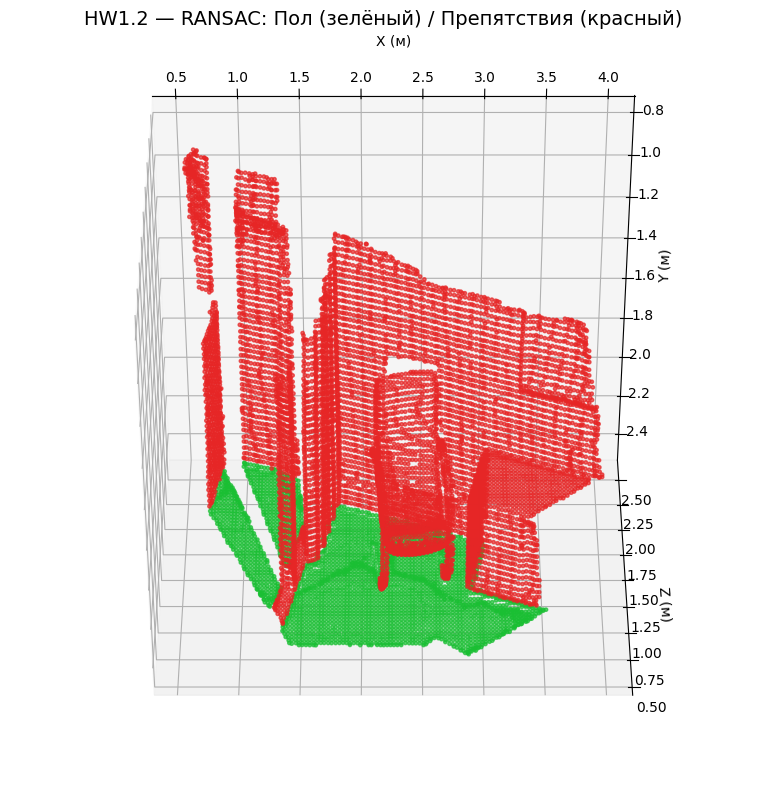

In [14]:
colors = np.full((len(points), 3), [0.9, 0.15, 0.15])  # красный
colors[inlier_mask] = [0.1, 0.75, 0.2]                 # зелёный

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=colors, s=6, alpha=0.7)
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')
ax.set_zlabel('Z (м)')
ax.set_title('HW1.2 — RANSAC: Пол (зелёный) / Препятствия (красный)', fontsize=14)
ax.view_init(elev=-50, azim=-90)
plt.tight_layout()
plt.savefig('images/ransac_ground.png', dpi=200, bbox_inches='tight')
plt.show()

## Итог задания 1.2

RANSAC успешно выделил плоскость пола. Точки пола окрашены зелёным, препятствия — красным.